In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
# Load Iris dataset from sklearn
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("First 5 rows:")
print(df.head())

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

In [ ]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.4798814508199817


In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hierarchical_labels

In [ ]:
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
print("Hierarchical Silhouette Score:", hierarchical_silhouette)

Hierarchical Silhouette Score: 0.4466890410285909


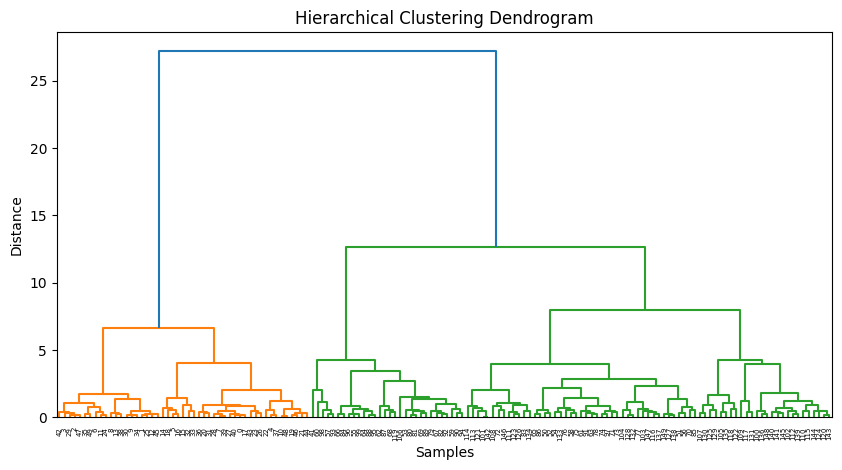

In [ ]:
plt.figure(figsize=(10,5))

linked = linkage(X_scaled, method='ward')
dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

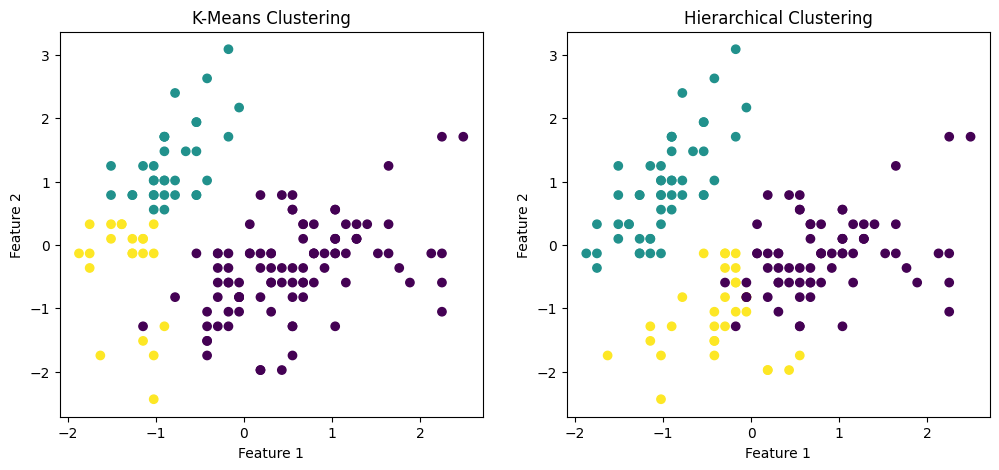

In [ ]:
plt.figure(figsize=(12,5))

# K-Means Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Hierarchical Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hierarchical_labels)
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()